# Rusty Bargain's Vehicle Worth Predictor

# Contents <a id='contents'></a>

[1. Contents](#contents)   
[2. Introduction](#introduction)  
[3. Project Goal](#project_goal)  
[4. Initialization](#initialization)  
[5. Load data](#load-data)  
[6. Data Description](#data-description)    
[7. Data Preparation](#data-preparation)  
[8.  Model Training](#model-training)   
[9. Model Analysisl](#model-analysis)   
[10. Conclusion](#conclusion)

# 1. Introduction <a id='introduction'></a> 
[Back to Contents](#contents)

**Rusty Bargain Used Car Sales Service** is developing an app to attract new customers. In this ambitious undertaking, we aim to develop an application that empowers users to precisely ascertain the market value of their vehicles. Leveraging historical data encompassing technical specifications, trim versions, and prices, we are set to build a cutting-edge machine learning model that will revolutionize the way individuals engage with the used car market.

# 2. Project Goal <a id='project-goal'></a> 
[Back to Contents](#contents)

The primary goal of the **Rusty Bargain Used Car Sales Service** App project is to develop an intelligent and user-friendly application that empowers individuals in the used car market. We aim to provide a robust and highly accurate machine learning model capable of swiftly and precisely determining the market value of a vehicle based on a wide range of factors, including technical specifications, trim versions, and historical pricing data. 

**Rusty Bargain** is interested in:

- the quality of the prediction;
- the speed of the prediction;
- the time required for training

# 3. Initialization <a id='initialization'></a>  
[Back to Contents](#contents)

In [ ]:
# Libraries for data preprocessing
import numpy as np
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
pd.options.mode.chained_assignment = None

# Libraries for for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Libraries for splitting and cross-validation using gridsearch
from sklearn.model_selection import train_test_split, GridSearchCV

# Libraries for measuring quality of model
from sklearn.metrics import mean_squared_error

# Libraries for machine learning models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

# 4. Load data <a id='load-data'></a>  
[Back to Contents](#contents)

The dataset is stored in file `./datasets/car_data.csv`. Let's load the data in the DataFrame - `df_car`:

In [ ]:
# Load the data from the file
df_car = pd.read_csv('./datasets/car_data.csv')

In [3]:
# Get first 10 rows of the DataFrame - df_car
df_car.head(10)

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,RegistrationMonth,FuelType,Brand,NotRepaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,24/03/2016 11:52,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,24/03/2016 00:00,0,70435,07/04/2016 03:16
1,24/03/2016 10:58,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,24/03/2016 00:00,0,66954,07/04/2016 01:46
2,14/03/2016 12:52,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,14/03/2016 00:00,0,90480,05/04/2016 12:47
3,17/03/2016 16:54,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,17/03/2016 00:00,0,91074,17/03/2016 17:40
4,31/03/2016 17:25,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,31/03/2016 00:00,0,60437,06/04/2016 10:17
5,04/04/2016 17:36,650,sedan,1995,manual,102,3er,150000,10,petrol,bmw,yes,04/04/2016 00:00,0,33775,06/04/2016 19:17
6,01/04/2016 20:48,2200,convertible,2004,manual,109,2_reihe,150000,8,petrol,peugeot,no,01/04/2016 00:00,0,67112,05/04/2016 18:18
7,21/03/2016 18:54,0,sedan,1980,manual,50,other,40000,7,petrol,volkswagen,no,21/03/2016 00:00,0,19348,25/03/2016 16:47
8,04/04/2016 23:42,14500,bus,2014,manual,125,c_max,30000,8,petrol,ford,NaN,04/04/2016 00:00,0,94505,04/04/2016 23:42
9,17/03/2016 10:53,999,small,1998,manual,101,golf,150000,0,NaN,volkswagen,NaN,17/03/2016 00:00,0,27472,31/03/2016 17:17


# 5. Data Description <a id='data-description'></a>  
[Back to Contents](#contents)

We've 15 features and 1 target in our DataFrame - `df_car`:

In [4]:
# Get list of columns
df_car.columns

Index(['DateCrawled', 'Price', 'VehicleType', 'RegistrationYear', 'Gearbox',
       'Power', 'Model', 'Mileage', 'RegistrationMonth', 'FuelType', 'Brand',
       'NotRepaired', 'DateCreated', 'NumberOfPictures', 'PostalCode',
       'LastSeen'],
      dtype='object')

| Feature           | Description                                        |
|:-------------------|:----------------------------------------------------|
| DateCrawled       | Date when the user profile was downloaded          |
| VehicleType       | Type or body style of the vehicle                  |
| RegistrationYear  | Year of vehicle registration                       |
| Gearbox           | Type of gearbox (e.g., automatic, manual)          |
| Power             | Power of the vehicle in horsepower (hp)            |
| Model             | Vehicle model name                                 |
| Mileage           | Mileage of the vehicle measured in kilometers (km) |
| RegistrationMonth | Month of vehicle registration                      |
| FuelType          | Type of fuel used by the vehicle                   |
| Brand             | Vehicle brand or manufacturer                      |
| NotRepaired       | Indicates if the vehicle has been repaired or not  |
| DateCreated       | Date of profile creation by the user               |
| NumberOfPictures  | Number of pictures of the vehicle                  |
| PostalCode        | Postal code of the profile owner (user)            |
| LastSeen          | Date of the last activity of the user              |
| Price (Target)    | Price of the vehicle in Euros                      |

The column names seems to be in **PascalCase**. It will be great to convert all of them to **snake_case**. We'll do it in the upcoming sections.

# 6. Data Preparation <a id='data-preparation'></a>  
[Back to Contents](#contents)

## Intial Analysis

Let's get some general information about the data:

In [5]:
# Get general information
df_car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Mileage            354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  NotRepaired        283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  LastSeen           354369 non-null  object
dtypes: int64(7), object(

According to the general information we got about the DataFrame - `df_car` above, we can make the following conclusions:

1. **Data Size**: The DataFrame contains a total of **354,369** rows and **16** columns, indicating a substantial amount of data for analysis.

2. **Missing Values**: Several columns have missing values - `VehicleType`, `Gearbox`, `Model`, `FuelType` and `NotRepaired`. We've to deal with missing values in these columns for accurate modeling.

3. **Data Types**: There are few columns where the datatypes are not the accurate. For example: `DateCrawled`, `DateCreated` and `LastSeen` should be of `datetime` type. We'll handle this later. 

Great! Let's get the descriptive statistics of the data:

In [6]:
# Get the descriptive statistics of only the categorical features
df_car.describe(include='object')

,DateCrawled,VehicleType,Gearbox,Model,FuelType,Brand,NotRepaired,DateCreated,LastSeen
count,354369,316879,334536,334664,321474,354369,283215,354369,354369
unique,15470,8,2,250,7,40,2,109,18592
top,05/03/2016 14:25,sedan,manual,golf,petrol,volkswagen,no,03/04/2016 00:00,07/04/2016 07:16
freq,66,91457,268251,29232,216352,77013,247161,13719,654


Based on the descriptive statistics for the categorical features we've got above, we can draw the following conclusions:

1. `DateCrawled`:
- There are `15470` unique values in the `DateCrawled` column.
- The most common date and time for data crawling is `05/03/2016 14:25`, which occurs `66` times.

2. `VehicleType`:
- There are `8` unique vehicle types in the `VehicleType` column.
- The most common vehicle type is `sedan`, which occurs `91,457` times.

3. `Gearbox`:
- There are `2` unique gearbox types in the `Gearbox` column.
- The most common gearbox type is `manual`, which occurs `268,251` times.

4. `Model`:
- There are `250` unique vehicle models in the `Model` column.
- The most common vehicle model is `golf`, which occurs `29,232` times.

5. `FuelType`:
- There are `7` unique fuel types in the `FuelType` column.
- The most common fuel type is `petrol`, which occurs `216,352` times.

6. `Brand`:
- There are `40` unique vehicle brands in the `Brand` column.
- The most common brand is `volkswagen`, which occurs `77,013` times.

7. `NotRepaired`:
- There are `2` unique values in the `NotRepaired` column.
- The most common value is `no`, indicating that most vehicles are listed as "not repaired."

8. `DateCreated`:
- There are `18,592` unique date and time values in the `DateCreated` column.
- The most common date and time for profile creation is `03/04/2016 00:00`, which occurs `13,719` times.

9. `LastSeen`:
- There are `18592` unique date and time values in the `LastSeen` column.
- The most common date and time for the last seen activity is `07/04/2016 07:16`, which occurs `654` times.

In [7]:
# Get the descriptive statistics of only the numerical features
df_car.describe()

,Price,RegistrationYear,Power,Mileage,RegistrationMonth,NumberOfPictures,PostalCode
count,354369.000000,354369.000000,354369.000000,354369.000000,354369.000000,354369.0,354369.000000
mean,4416.656776,2004.234448,110.094337,128211.172535,5.714645,0.0,50508.689087
std,4514.158514,90.227958,189.850405,37905.341530,3.726421,0.0,25783.096248
min,0.000000,1000.000000,0.000000,5000.000000,0.000000,0.0,1067.000000
25%,1050.000000,1999.000000,69.000000,125000.000000,3.000000,0.0,30165.000000
50%,2700.000000,2003.000000,105.000000,150000.000000,6.000000,0.0,49413.000000
75%,6400.000000,2008.000000,143.000000,150000.000000,9.000000,0.0,71083.000000
max,20000.000000,9999.000000,20000.000000,150000.000000,12.000000,0.0,99998.000000


Based on the descriptive statistics for the numerical features we've got above, we can draw the following conclusions:

1. `Price`:
- The mean price is approximately `€4,416.66`, with a wide range of prices ranging from `€0` to `€20,000`.
- **The majority of listings have prices below `€6,400`**, as indicated by the 75th percentile.  

2. `RegistrationYear`:
- The average registration year is around `2004.23`, suggesting that **most vehicles in the dataset are relatively old**.

3. `Power`:
- The average power is approximately `110.09 hp`, with a wide range of values.
- There are vehicles with very low power (minimum of 0 hp) and very high power (maximum of 20,000 hp), indicating **potential data errors or outliers**.

4. `Mileage`:
- The average mileage is approximately `128,211.17 km`.
- The mileage ranges from `5,000 km` to the maximum value of `150,000 km`.

5. `RegistrationMonth`:
- The values in this column range from `0` to `12`, with `0` possibly indicating missing or unspecified values.

6. `NumberOfPictures`:
- **The `NumberOfPictures` column appears to contain only zeros (0.0), which suggests that there may be no pictures available for the listed vehicles**. This column may not provide useful information for analysis.

7. `PostalCode`:
- The dataset contains a wide range of postal codes, with a minimum of `1,067` and a maximum of `99,998`.

Great! Let's check if we have null values in the data:

In [8]:
# Get no of missing values in each column
df_car.isna().sum()

DateCrawled              0
Price                    0
VehicleType          37490
RegistrationYear         0
Gearbox              19833
Power                    0
Model                19705
Mileage                  0
RegistrationMonth        0
FuelType             32895
Brand                    0
NotRepaired          71154
DateCreated              0
NumberOfPictures         0
PostalCode               0
LastSeen                 0
dtype: int64

**The missing values are present in five columns** - `VehicleType`, `Gearbox`, `Model`, `FuelType`, and `NotRepaired`. We'll handle these missing values appropriately during data preprocessing stage. Also, the `NumberOfPictures` column contains only zeros (as we saw in the previous step), which may not be required for the analysis and can be considered for removal.

In [9]:
# Get the number of duplicate rows
df_car.duplicated().sum()

262

**We've 262 duplicate rows** in the data that we'll handle appropriately during data preprocessing stage.

## Rename the column names

As already mentioned above that the column names seems to be in **PascalCase**. It will be great to convert all of them to **snake_case**. Let's do it:

In [10]:
# Rename columns to snake_case
new_column_names = {
    'DateCrawled': 'date_crawled',
    'Price': 'price',
    'VehicleType': 'vehicle_type',
    'RegistrationYear': 'registration_year',
    'Gearbox': 'gearbox',
    'Power': 'power',
    'Model': 'model',
    'Mileage': 'mileage',
    'RegistrationMonth': 'registration_month',
    'FuelType': 'fuel_type',
    'Brand': 'brand',
    'NotRepaired': 'not_repaired',
    'DateCreated': 'date_created',
    'NumberOfPictures': 'number_of_pictures',
    'PostalCode': 'postal_code',
    'LastSeen': 'last_seen',
}

df_car = df_car.rename(columns=new_column_names)

Awesome! Let's validate the change:

In [11]:
# Get all the column names
df_car.columns

Index(['date_crawled', 'price', 'vehicle_type', 'registration_year', 'gearbox',
       'power', 'model', 'mileage', 'registration_month', 'fuel_type', 'brand',
       'not_repaired', 'date_created', 'number_of_pictures', 'postal_code',
       'last_seen'],
      dtype='object')

## Handle missing values

As we saw earlier that we've missing values in five columns - `VehicleType`, `Gearbox`, `Model`, `FuelType`, and `NotRepaired`:

In [12]:
# Get no of missing values in each column
df_car.isna().sum()

date_crawled              0
price                     0
vehicle_type          37490
registration_year         0
gearbox               19833
power                     0
model                 19705
mileage                   0
registration_month        0
fuel_type             32895
brand                     0
not_repaired          71154
date_created              0
number_of_pictures        0
postal_code               0
last_seen                 0
dtype: int64

### `model` feature

We'll try filling missing values in the `model` column using information from the `brand` column. Here's a step-by-step process that we'll follow:

1. **Identify Unique Brands**: First, identify all the unique brands present in the `brand` column.

2. **Group Data by Brand**: Group the dataset - `df_car` by each unique brand.

3. **Calculate the Mode (Most Frequent Model) for Each Brand**: Within each brand's subset, calculate the mode (most frequent value) of the `model` column. This mode represents the most common model associated with that brand.

4. **Fill Missing Values**: For each row with a missing value in the `model` column, determine the brand of the vehicle. Then, fill in the missing `model` value with the corresponding mode for that brand.

In [13]:
# Identify unique brands
unique_brands = df_car['brand'].unique().tolist()

# Iterate through each unique brand
for brand in unique_brands:
    # Calculate the mode for 'model' within each brand group
    mode_model_values = df_car[df_car['brand'] == brand]['model'].mode().values
    
    # Check if we have a mode value (if the brand has atleast some valid values for model column)
    if len(mode_model_values) > 0:
        mode_model = mode_model_values[0]
    else:
        # If there is not a single valid value for model column, fill the missing value with unknown
        mode_model = 'unknown'
    
    # Fill missing 'model' values for that brand with the mode
    df_car.loc[(df_car['brand'] == brand) & (df_car['model'].isnull()), 'model'] = mode_model

Great! Let's validate if we have any more missing values for `model` column:

In [14]:
# Check if we have any missing values for model column
df_car['model'].isna().sum()

0

Great! We don't have any missing values in the `model` column now.

### `vehicle_type` feature

In [15]:
# Get no of missing values in each column
df_car.isna().sum()

date_crawled              0
price                     0
vehicle_type          37490
registration_year         0
gearbox               19833
power                     0
model                     0
mileage                   0
registration_month        0
fuel_type             32895
brand                     0
not_repaired          71154
date_created              0
number_of_pictures        0
postal_code               0
last_seen                 0
dtype: int64

In [16]:
# Get first 10 records from teh dataset
df_car.head(10)

,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,mileage,registration_month,fuel_type,brand,not_repaired,date_created,number_of_pictures,postal_code,last_seen
0,24/03/2016 11:52,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,24/03/2016 00:00,0,70435,07/04/2016 03:16
1,24/03/2016 10:58,18300,coupe,2011,manual,190,a4,125000,5,gasoline,audi,yes,24/03/2016 00:00,0,66954,07/04/2016 01:46
2,14/03/2016 12:52,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,14/03/2016 00:00,0,90480,05/04/2016 12:47
3,17/03/2016 16:54,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,17/03/2016 00:00,0,91074,17/03/2016 17:40
4,31/03/2016 17:25,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,31/03/2016 00:00,0,60437,06/04/2016 10:17
5,04/04/2016 17:36,650,sedan,1995,manual,102,3er,150000,10,petrol,bmw,yes,04/04/2016 00:00,0,33775,06/04/2016 19:17
6,01/04/2016 20:48,2200,convertible,2004,manual,109,2_reihe,150000,8,petrol,peugeot,no,01/04/2016 00:00,0,67112,05/04/2016 18:18
7,21/03/2016 18:54,0,sedan,1980,manual,50,other,40000,7,petrol,volkswagen,no,21/03/2016 00:00,0,19348,25/03/2016 16:47
8,04/04/2016 23:42,14500,bus,2014,manual,125,c_max,30000,8,petrol,ford,NaN,04/04/2016 00:00,0,94505,04/04/2016 23:42
9,17/03/2016 10:53,999,small,1998,manual,101,golf,150000,0,NaN,volkswagen,NaN,17/03/2016 00:00,0,27472,31/03/2016 17:17


We'll try filling missing values in the `vehicle_type` column using a combination of `brand` and `model` columns. Here's a step-by-step process that we'll follow:

1. **Group Data by Relevant Features - `brand` and `model`**: Group the dataset by combinations of related features that makes sense, like - `brand` and `model` to find common vehicle types associated with specific brands and models.

2. **Calculate the Mode (Most Frequent Vehicle Type) for Each Group**: Within each group, calculate the mode (most frequent value) of the `vehicle_type` column. This mode represents the most common vehicle type associated with that combination of features.

3. **Fill Missing Values**: For each row with a missing `vehicle_type`, determine the values in related columns (e.g., "Brand" and "Model") and use this information to fill in the missing `vehicle_type` based on the corresponding mode for that group.

In [17]:
# Get the list of related features
related_features = ['brand', 'model']

# Iterate through each combination of related features
for feature_combination in df_car[related_features].drop_duplicates().itertuples(index=False):
    # Create a filter to select rows with the same feature combination
    filter_condition = (df_car['brand'] == feature_combination.brand) & (df_car['model'] == feature_combination.model)
    
    # Calculate the mode for 'vehicle_type' within the group
    mode_vehicle_type = df_car[filter_condition]['vehicle_type'].mode().values[0]
    
    # Fill missing 'vehicle_type' values in the group with the mode
    df_car.loc[filter_condition & df_car['vehicle_type'].isnull(), 'vehicle_type'] = mode_vehicle_type


Great! Let's validate if we have any more missing values for `vehicle_type` column:

In [18]:
# Check if we have any missing values for vehicle_type column
df_car['vehicle_type'].isna().sum()

0

### `fuel_type` feature

In [19]:
# Get no of missing values in each column
df_car.isna().sum()

date_crawled              0
price                     0
vehicle_type              0
registration_year         0
gearbox               19833
power                     0
model                     0
mileage                   0
registration_month        0
fuel_type             32895
brand                     0
not_repaired          71154
date_created              0
number_of_pictures        0
postal_code               0
last_seen                 0
dtype: int64

In [20]:
# Get first 10 records from teh dataset
df_car.head(10)

,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,mileage,registration_month,fuel_type,brand,not_repaired,date_created,number_of_pictures,postal_code,last_seen
0,24/03/2016 11:52,480,sedan,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,24/03/2016 00:00,0,70435,07/04/2016 03:16
1,24/03/2016 10:58,18300,coupe,2011,manual,190,a4,125000,5,gasoline,audi,yes,24/03/2016 00:00,0,66954,07/04/2016 01:46
2,14/03/2016 12:52,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,14/03/2016 00:00,0,90480,05/04/2016 12:47
3,17/03/2016 16:54,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,17/03/2016 00:00,0,91074,17/03/2016 17:40
4,31/03/2016 17:25,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,31/03/2016 00:00,0,60437,06/04/2016 10:17
5,04/04/2016 17:36,650,sedan,1995,manual,102,3er,150000,10,petrol,bmw,yes,04/04/2016 00:00,0,33775,06/04/2016 19:17
6,01/04/2016 20:48,2200,convertible,2004,manual,109,2_reihe,150000,8,petrol,peugeot,no,01/04/2016 00:00,0,67112,05/04/2016 18:18
7,21/03/2016 18:54,0,sedan,1980,manual,50,other,40000,7,petrol,volkswagen,no,21/03/2016 00:00,0,19348,25/03/2016 16:47
8,04/04/2016 23:42,14500,bus,2014,manual,125,c_max,30000,8,petrol,ford,NaN,04/04/2016 00:00,0,94505,04/04/2016 23:42
9,17/03/2016 10:53,999,small,1998,manual,101,golf,150000,0,NaN,volkswagen,NaN,17/03/2016 00:00,0,27472,31/03/2016 17:17


We'll try filling missing values in the `fuel_type` column using a combination of `brand` and `model` columns in a similar way as in the previous step:

In [21]:
# Get the list of related features
related_features = ['brand', 'model']

# Iterate through each combination of related features
for feature_combination in df_car[related_features].drop_duplicates().itertuples(index=False):
    # Create a filter to select rows with the same feature combination
    filter_condition = (df_car['brand'] == feature_combination.brand) & (df_car['model'] == feature_combination.model)
    
    # Calculate the mode for 'fuel_type' within the group
    mode_fuel_type = df_car[filter_condition]['fuel_type'].mode().values[0]
    
    # Fill missing 'fuel_type' values in the group with the mode
    df_car.loc[filter_condition & df_car['fuel_type'].isnull(), 'fuel_type'] = mode_fuel_type


Great! Let's validate if we have any more missing values for `fuel_type` column:

In [22]:
# Check if we have any missing values for fuel_type column
df_car['fuel_type'].isna().sum()

0

### `gearbox` feature

In [23]:
# Get no of missing values in each column
df_car.isna().sum()

date_crawled              0
price                     0
vehicle_type              0
registration_year         0
gearbox               19833
power                     0
model                     0
mileage                   0
registration_month        0
fuel_type                 0
brand                     0
not_repaired          71154
date_created              0
number_of_pictures        0
postal_code               0
last_seen                 0
dtype: int64

In [24]:
# Get first 10 records from the dataset
df_car.head(10)

,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,mileage,registration_month,fuel_type,brand,not_repaired,date_created,number_of_pictures,postal_code,last_seen
0,24/03/2016 11:52,480,sedan,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,24/03/2016 00:00,0,70435,07/04/2016 03:16
1,24/03/2016 10:58,18300,coupe,2011,manual,190,a4,125000,5,gasoline,audi,yes,24/03/2016 00:00,0,66954,07/04/2016 01:46
2,14/03/2016 12:52,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,14/03/2016 00:00,0,90480,05/04/2016 12:47
3,17/03/2016 16:54,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,17/03/2016 00:00,0,91074,17/03/2016 17:40
4,31/03/2016 17:25,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,31/03/2016 00:00,0,60437,06/04/2016 10:17
5,04/04/2016 17:36,650,sedan,1995,manual,102,3er,150000,10,petrol,bmw,yes,04/04/2016 00:00,0,33775,06/04/2016 19:17
6,01/04/2016 20:48,2200,convertible,2004,manual,109,2_reihe,150000,8,petrol,peugeot,no,01/04/2016 00:00,0,67112,05/04/2016 18:18
7,21/03/2016 18:54,0,sedan,1980,manual,50,other,40000,7,petrol,volkswagen,no,21/03/2016 00:00,0,19348,25/03/2016 16:47
8,04/04/2016 23:42,14500,bus,2014,manual,125,c_max,30000,8,petrol,ford,NaN,04/04/2016 00:00,0,94505,04/04/2016 23:42
9,17/03/2016 10:53,999,small,1998,manual,101,golf,150000,0,petrol,volkswagen,NaN,17/03/2016 00:00,0,27472,31/03/2016 17:17


We'll try filling missing values in the `gearbox` column using a combination of `brand` and `model` columns in a similar way as in the previous steps for `vehicle_type` and `fuel_type`:

In [25]:
# Get the list of related features
related_features = ['brand', 'model']

# Iterate through each combination of related features
for feature_combination in df_car[related_features].drop_duplicates().itertuples(index=False):
    # Create a filter to select rows with the same feature combination
    filter_condition = (df_car['brand'] == feature_combination.brand) & (df_car['model'] == feature_combination.model)
    
    # Calculate the mode for 'gearbox' within the group
    mode_gearbox = df_car[filter_condition]['gearbox'].mode().values[0]
    
    # Fill missing 'gearbox' values in the group with the mode
    df_car.loc[filter_condition & df_car['gearbox'].isnull(), 'gearbox'] = mode_gearbox

Great! Let's validate if we have any more missing values for `gearbox` column:

In [26]:
# Check if we have any missing values for gearbox column
df_car['gearbox'].isna().sum()

0

### `not_repaired` feature

In [27]:
# Get no of missing values in each column
df_car.isna().sum()

date_crawled              0
price                     0
vehicle_type              0
registration_year         0
gearbox                   0
power                     0
model                     0
mileage                   0
registration_month        0
fuel_type                 0
brand                     0
not_repaired          71154
date_created              0
number_of_pictures        0
postal_code               0
last_seen                 0
dtype: int64

In [28]:
# Get first 10 records from the dataset
df_car.head(10)

,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,mileage,registration_month,fuel_type,brand,not_repaired,date_created,number_of_pictures,postal_code,last_seen
0,24/03/2016 11:52,480,sedan,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,24/03/2016 00:00,0,70435,07/04/2016 03:16
1,24/03/2016 10:58,18300,coupe,2011,manual,190,a4,125000,5,gasoline,audi,yes,24/03/2016 00:00,0,66954,07/04/2016 01:46
2,14/03/2016 12:52,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,14/03/2016 00:00,0,90480,05/04/2016 12:47
3,17/03/2016 16:54,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,17/03/2016 00:00,0,91074,17/03/2016 17:40
4,31/03/2016 17:25,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,31/03/2016 00:00,0,60437,06/04/2016 10:17
5,04/04/2016 17:36,650,sedan,1995,manual,102,3er,150000,10,petrol,bmw,yes,04/04/2016 00:00,0,33775,06/04/2016 19:17
6,01/04/2016 20:48,2200,convertible,2004,manual,109,2_reihe,150000,8,petrol,peugeot,no,01/04/2016 00:00,0,67112,05/04/2016 18:18
7,21/03/2016 18:54,0,sedan,1980,manual,50,other,40000,7,petrol,volkswagen,no,21/03/2016 00:00,0,19348,25/03/2016 16:47
8,04/04/2016 23:42,14500,bus,2014,manual,125,c_max,30000,8,petrol,ford,NaN,04/04/2016 00:00,0,94505,04/04/2016 23:42
9,17/03/2016 10:53,999,small,1998,manual,101,golf,150000,0,petrol,volkswagen,NaN,17/03/2016 00:00,0,27472,31/03/2016 17:17


`not_repaired` column indicates if the vehicle has been repaired or not. Logically, it is hard to derive this value from any of the other car features. So, let's fill all the missing values for the `not_repaired` with `unknown`:

In [29]:
# Fill all the missing values for the not_repaired with unknown
df_car['not_repaired'] = df_car['not_repaired'].fillna('unknown')

In [30]:
# Check if we have any missing values for not_repaired column
df_car['not_repaired'].isna().sum()

0

In [31]:
# Check the list of unique values in not_repaired column
df_car['not_repaired'].unique()

array(['unknown', 'yes', 'no'], dtype=object)

Great! So, we've covered all the features, let's validate once more that we have no more missing value sin the DataFrame - `df_car`:

In [32]:
# Get no of missing values in each column
df_car.isna().sum()

date_crawled          0
price                 0
vehicle_type          0
registration_year     0
gearbox               0
power                 0
model                 0
mileage               0
registration_month    0
fuel_type             0
brand                 0
not_repaired          0
date_created          0
number_of_pictures    0
postal_code           0
last_seen             0
dtype: int64

Awesome! Let's proceed.

## Handle duplicates

As we already know that **we've duplicate rows in the data**:

In [33]:
# Get the number of duplicate rows
df_car.duplicated().sum()

273

It seems, while replacing missing values we've inserted a few more duplicate rows in addition to what we already had. Either way, let's get rid of them:

In [34]:
# Drop all the duplicate rows from the dataset
df_car = df_car.drop_duplicates()

Let's validate if all the duplicate rows were successfully removed from the dataset:

In [35]:
# Get the number of duplicate rows
df_car.duplicated().sum()

0

## Update column datatypes

As we discussed before that there are few columns where the datatypes are not accurate. For example: `date_crawled`, `date_created` and `last_seen` should be of `datetime` type. Let's check their datatype once again and change them to `datetime`:

In [36]:
# Get the datatypes of all the columns
df_car.dtypes

date_crawled          object
price                  int64
vehicle_type          object
registration_year      int64
gearbox               object
power                  int64
model                 object
mileage                int64
registration_month     int64
fuel_type             object
brand                 object
not_repaired          object
date_created          object
number_of_pictures     int64
postal_code            int64
last_seen             object
dtype: object

In [37]:
# Change the columns datatype
columns_to_change = ['date_crawled', 'date_created', 'last_seen']

for column in columns_to_change:
    df_car[column] = pd.to_datetime(df_car[column])

In [38]:
# Get the datatypes of the selected columns
df_car[columns_to_change].dtypes

date_crawled    datetime64[ns]
date_created    datetime64[ns]
last_seen       datetime64[ns]
dtype: object

## Exploratory Data Analysis

We'll perform some basic Exploratory Data Analysis (EDA) to understand the spread and nature of our data.

### Distribution & Box Plots for numerical features

Let's create histograms for numerical features to visualize their distributions. This can help us identify skewness, outliers, and patterns in the data:

In [39]:
# Get list of numerical features that are sensible to study distribution for
numerical_features = ['price', 'power', 'mileage']

In [40]:
df_car[numerical_features].describe()

,price,power,mileage
count,354096.000000,354096.000000,354096.000000
mean,4416.340108,110.088990,128212.433916
std,4514.265158,189.917382,37906.647058
min,0.000000,0.000000,5000.000000
25%,1050.000000,69.000000,125000.000000
50%,2700.000000,105.000000,150000.000000
75%,6400.000000,143.000000,150000.000000
max,20000.000000,20000.000000,150000.000000


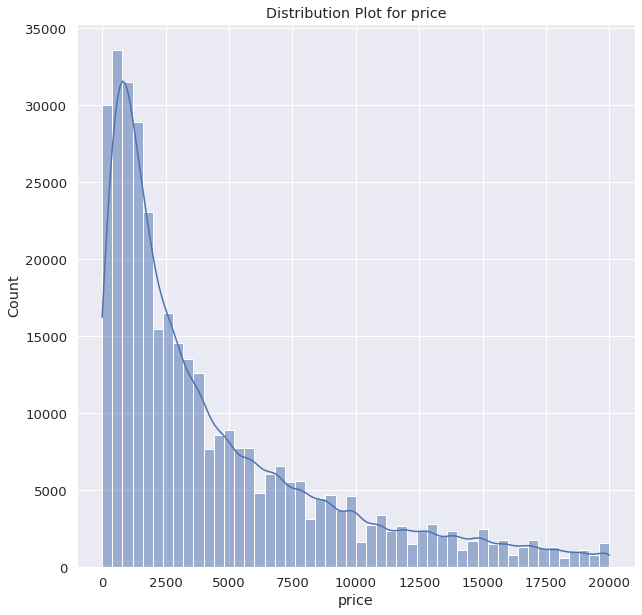

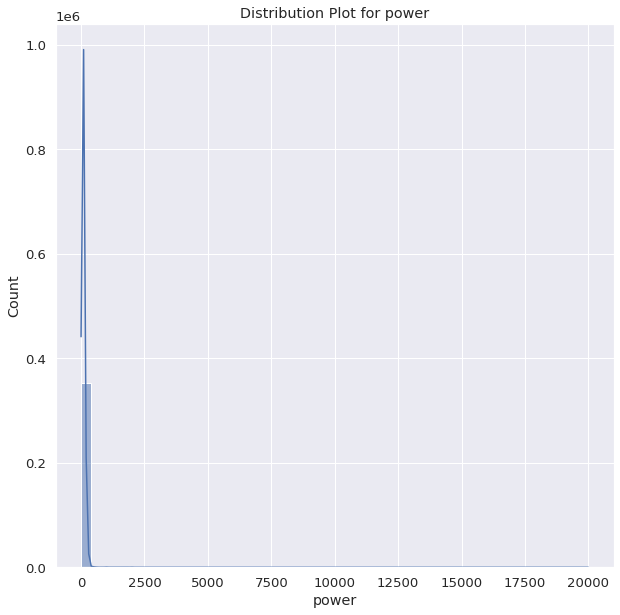

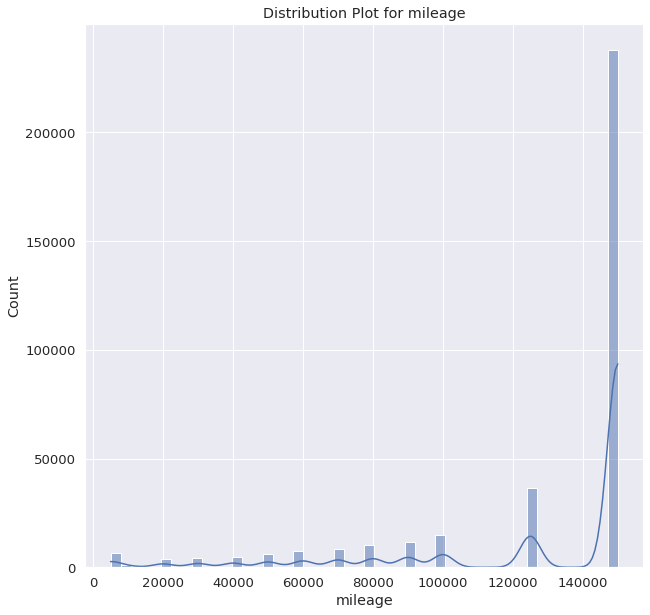

In [41]:
# Plot histograms for numerical features
for feature in numerical_features:
    # Set bar plot style properties
    sns.set(rc = {'figure.figsize':(10.0, 10.0)})
    sns.set(font_scale = 1.2)
    
    # Plot the Histogram
    ax = sns.histplot(data=df_car, x=feature, kde=True, bins=50)
    plot_title = f'Distribution Plot for {feature}'
    ax.set(title=plot_title)
    plt.show()

Let's make box plots for theses numerical features:

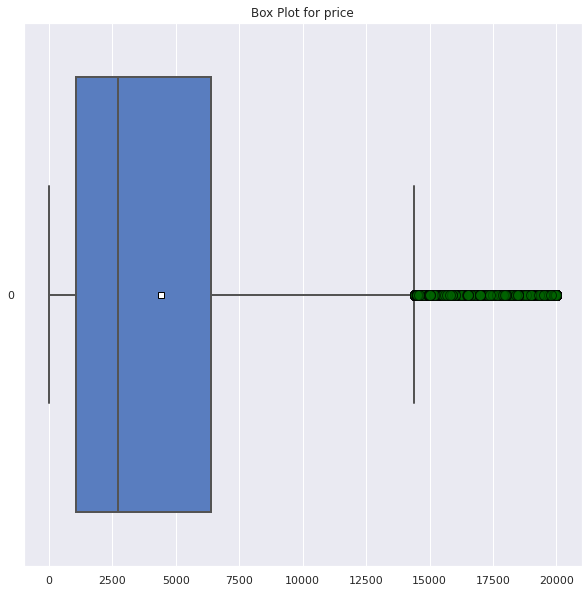

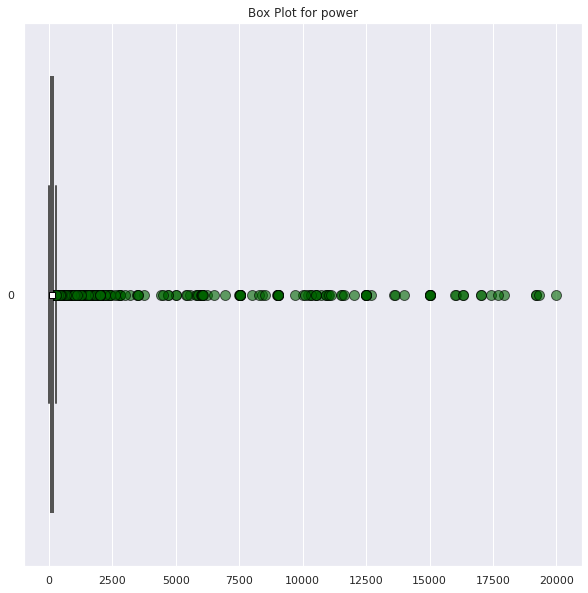

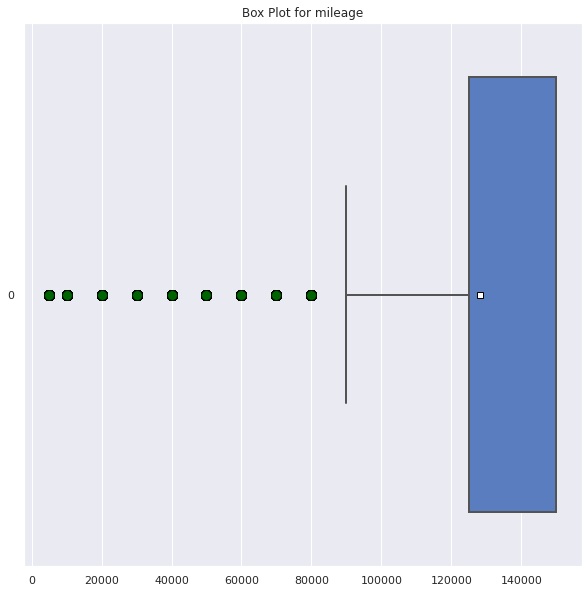

In [42]:
# Plot boxplots for numerical features
for feature in numerical_features:
    # Set box plot style properties
    sns.set(rc = {'figure.figsize':(10.0, 10.0)})
    
    # Customize the markers that show outliers in the data
    flierprops = dict(marker='o', markersize=10, markeredgecolor='black', markerfacecolor='darkgreen', alpha=0.6)

    # Customize the markers that show mean values
    meanprops = dict(marker='s', markerfacecolor='white', markeredgecolor='black')

    ax = sns.boxplot(
        data=df_car[feature],
        showmeans=True,
        orient='h',
        linewidth=2,
        flierprops=flierprops,
        meanprops=meanprops,
        palette='muted')
    plot_title = f'Box Plot for {feature}'
    ax.set(title=plot_title)
    plt.show()

We can draw the many conclusions about the distribution of the numerical features based on the plots and the descriptive statistics above:

1. **Price**:
- **The distribution of prices is right-skewed**, as indicated by the higher mean (€4,416.34) compared to the median (€2,700.00).
- **There are outliers at the upper end**, as evidenced by the maximum price of €20,000.00.
- **Most prices fall below €6,400.00**, as indicated by the 75th percentile.

2. **Power**:
- **The distribution of power (in horsepower, hp) is right-skewed**, as the mean power (110.09 hp) is higher than the median (105.00 hp).
- **There are outliers at the upper end**, with the maximum power reaching 20,000 hp, **which is likely an error or an extreme outlier**. We'll have to dig deep into this to check how much maximum horsepower do car have.
- **The majority of vehicles have power below 143 hp**, as indicated by the 75th percentile.

3. **Mileage**:
- The distribution of mileage (in kilometers, km) appears to be comparitively uniform, as the mean (128,212.43 km) is close to the median (150,000.00 km).
- **The dataset predominantly contains vehicles with high mileage**, as most have a mileage of 150,000 km (maximum value).

### Check if there is an error in the values of  `power` feature

Let's check again the descriptive statistics of `power` feature again:

In [43]:
# Get descriptive statistics of power
df_car['power'].describe()

count    354096.000000
mean        110.088990
std         189.917382
min           0.000000
25%          69.000000
50%         105.000000
75%         143.000000
max       20000.000000
Name: power, dtype: float64

It's weird that the column has its maximum value as `20000 HP` as its not normal horsepower for cars. If we search the internet, the most powerful car has horsepower of `5007` (i.e Devel Sixteen). Here is the reference - [20 Most Powerful Production Cars In The World](https://www.topspeed.com/10-most-powerful-production-cars-in-the-world). And also, since we are dealing with used car historical data, by no means we'll have horse power greater than `5007`. So, let's get all the records where `power` is greater than `5007`:

In [44]:
df_car[df_car['power'] > 5007]

,date_crawled,price,vehicle_type,registration_year,gearbox,power,model,mileage,registration_month,fuel_type,brand,not_repaired,date_created,number_of_pictures,postal_code,last_seen
7661,2016-02-04 19:25:00,1499,small,1999,manual,7515,lupo,150000,4,petrol,volkswagen,unknown,2016-02-04,0,65830,2016-06-04 11:46:00
11039,2016-03-25 19:55:00,0,sedan,1998,manual,10317,other,150000,8,petrol,fiat,no,2016-03-25,0,57520,2016-01-04 19:16:00
25232,2016-03-28 19:57:00,10900,bus,2009,manual,10520,caddy,150000,6,gasoline,volkswagen,no,2016-03-28,0,36272,2016-07-04 02:47:00
33952,2016-09-03 11:37:00,3740,small,2006,manual,6920,aygo,90000,10,petrol,toyota,no,2016-09-03,0,94116,2016-03-17 05:16:00
44520,2016-10-03 22:37:00,2500,convertible,1998,manual,7512,golf,150000,6,petrol,volkswagen,unknown,2016-10-03,0,68239,2016-05-04 15:17:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328862,2016-03-20 09:57:00,850,small,2000,manual,8500,corsa,150000,3,petrol,opel,no,2016-03-20,0,26721,2016-04-04 05:50:00
339642,2016-07-03 16:58:00,600,sedan,2000,manual,10110,focus,125000,12,petrol,ford,unknown,2016-07-03,0,35066,2016-07-03 17:41:00
341320,2016-03-29 21:40:00,1899,other,2006,manual,7518,berlingo,125000,11,petrol,citroen,yes,2016-03-29,0,89428,2016-03-31 15:17:00
346639,2016-03-25 12:55:00,1300,sedan,2000,manual,12512,carisma,150000,9,petrol,mitsubishi,unknown,2016-03-25,0,42105,2016-06-04 14:44:00


In [45]:
# Count of records
df_car[df_car['power'] > 5007].shape[0]

82

We have atleast 82 records with potential errors in `power` values. Let's get rid of them:

In [46]:
# Filter the data
df_car = df_car[df_car['power'] <= 5007]

In [47]:
# Validate the data
df_car[df_car['power'] > 5007].shape[0]

0

### Count Plots for categorical features

Let's create count plots for categorical features to visualize the distribution of categories within each feature:

In [48]:
# Get list of categorical features that are sensible to study distribution for
categorical_features = ['vehicle_type', 'gearbox', 'fuel_type', 'brand', 'not_repaired']

In [49]:
df_car[categorical_features].describe(include=object)

,vehicle_type,gearbox,fuel_type,brand,not_repaired
count,354014,354014,354014,354014,354014
unique,8,2,7,40,3
top,sedan,manual,petrol,volkswagen,no
freq,108043,285720,243508,76939,246873


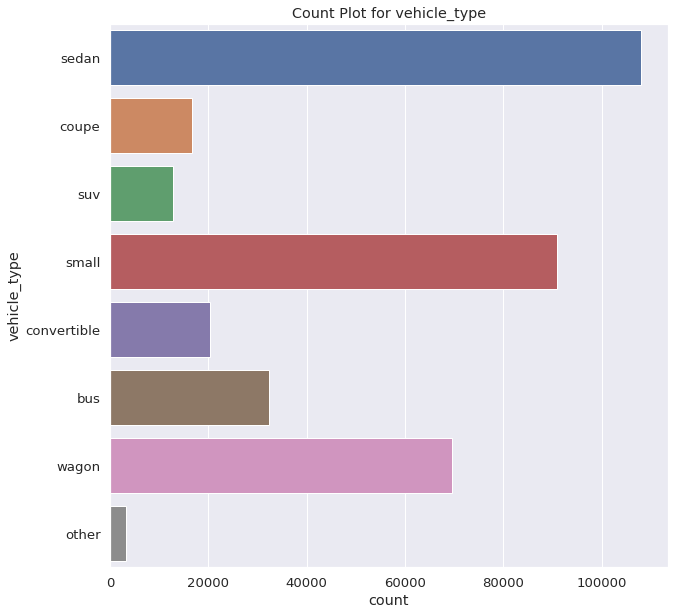

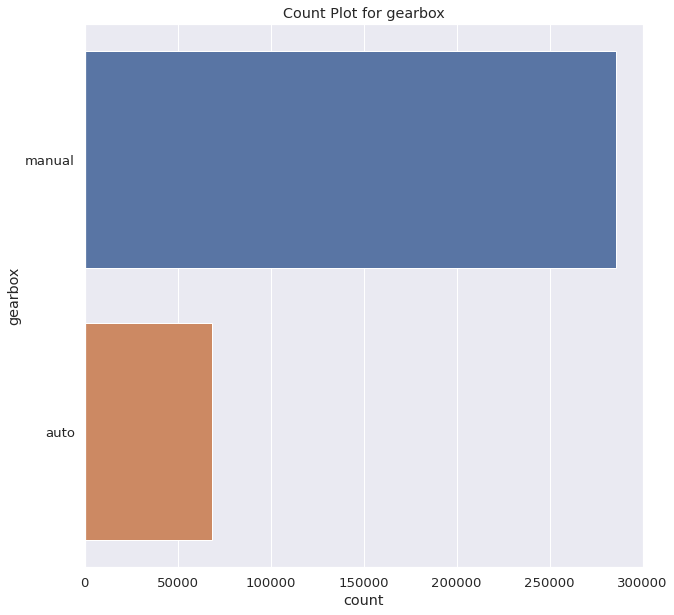

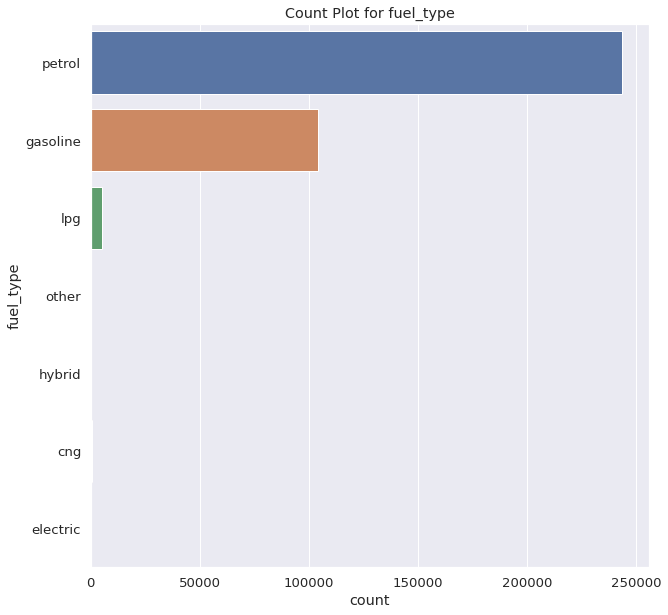

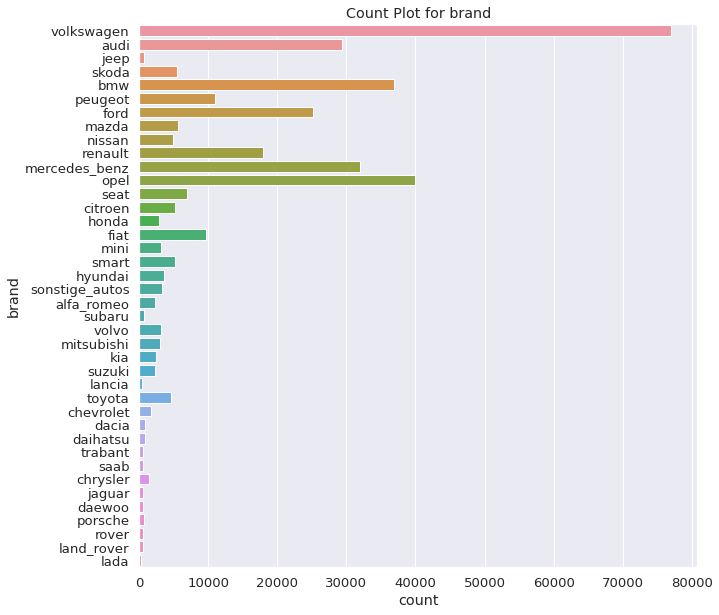

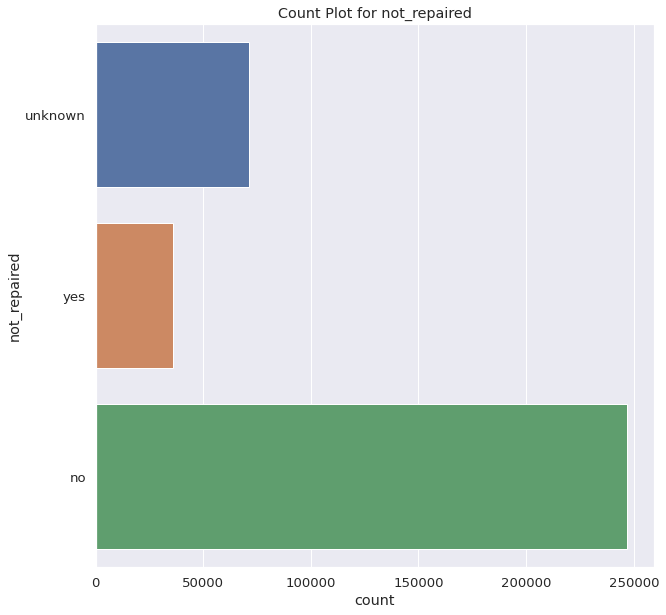

In [50]:
# Plot countplots for categorical features
for feature in categorical_features:
    # Set bar plot style properties
    sns.set(rc = {'figure.figsize':(10.0, 10.0)})
    sns.set(font_scale = 1.2)
    
    # Plot the Countplot
    ax = sns.countplot(y=df_car[feature])
    plot_title = f'Count Plot for {feature}'
    ax.set(title=plot_title)
    plt.show()

From the count plot for `fuel_type` we can see that there are 7 unique fuel types in the dataset with 'petrol' and 'gasoline' as the separate values. Petrol and gasoline are actually the same thing; just different words. These two words have the same meaning, with the only difference being in the places where the words are used. The term 'petrol' is used in UK, India and a few other places, while 'gasoline' or 'gas for short' is used in the United States. 

So, let's replace all the occurrences of 'gasoline' with 'petrol' and get the descriptive statistics and plot the count plot again:

In [51]:
# Replace all the occurrences of 'gasoline' with 'petrol'
df_car['fuel_type'] = df_car['fuel_type'].replace('gasoline', 'petrol')
df_car['fuel_type'].unique()

array(['petrol', 'lpg', 'other', 'hybrid', 'cng', 'electric'],
      dtype=object)

In [52]:
# Get the descriptive statistics
df_car['fuel_type'].describe()

count     354014
unique         6
top       petrol
freq      347615
Name: fuel_type, dtype: object

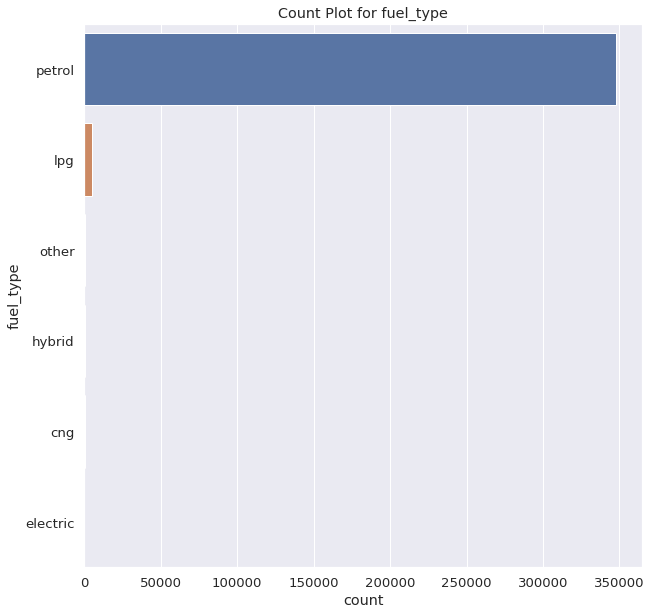

In [53]:
# Plot the count plot for fuel_type
# Set bar plot style properties
sns.set(rc = {'figure.figsize':(10.0, 10.0)})
sns.set(font_scale = 1.2)

# Plot the Countplot
ax = sns.countplot(y=df_car['fuel_type'])
plot_title = f'Count Plot for fuel_type'
ax.set(title=plot_title)
plt.show()

We can draw the many conclusions about the distribution of the categorical features based on the count plots and the descriptive statistics above:

1. **Vehicle Type**:
- There are **8 unique vehicle types** in the dataset.
- **"Sedan" is the most frequent vehicle type**, occurring 108,043 times, indicating that sedans are the most common body type among the listings.
- The distribution of vehicle types varies, with some types appearing more frequently than others.

2. **Gearbox**:
- There are **2 unique gearbox types**, namely "manual" and "auto.
- **"Manual" gearboxes are the most common**, occurring 285,720 times, suggesting that the majority of vehicles in the dataset have manual transmissions.

3. **Fuel Type**:
- There are **6 unique fuel types** in the dataset.
- **"Petrol" is the most frequent fuel type**, occurring 243,508 times, indicating that petrol-powered vehicles are prevalent among the listings.

4. **Brand**:
- There are **40 unique vehicle brands** in the dataset.
- **"Volkswagen" is the most frequent brand**, appearing 76, 939 times, suggesting that Volkswagen vehicles are heavily represented in the listings.

5. **Not Repaired**:
- There are **3 unique values in the `not_repaired` column, representing whether a vehicle has been repaired or not.
- **"No" is the most frequent value**, occurring 246,873 times, suggesting that a significant portion of the listings indicates that the vehicles have not been repaired.

### Removing records with other potential outliers

Let's investigate the values of `registration_year` column a bit more:

In [54]:
# Get unique values
df_car['registration_year'].sort_values().unique().tolist()

[1000,
 1001,
 1039,
 1111,
 1200,
 1234,
 1253,
 1255,
 1300,
 1400,
 1500,
 1600,
 1602,
 1688,
 1800,
 1910,
 1915,
 1919,
 1920,
 1923,
 1925,
 1927,
 1928,
 1929,
 1930,
 1931,
 1932,
 1933,
 1934,
 1935,
 1936,
 1937,
 1938,
 1940,
 1941,
 1942,
 1943,
 1944,
 1945,
 1946,
 1947,
 1948,
 1949,
 1950,
 1951,
 1952,
 1953,
 1954,
 1955,
 1956,
 1957,
 1958,
 1959,
 1960,
 1961,
 1962,
 1963,
 1964,
 1965,
 1966,
 1967,
 1968,
 1969,
 1970,
 1971,
 1972,
 1973,
 1974,
 1975,
 1976,
 1977,
 1978,
 1979,
 1980,
 1981,
 1982,
 1983,
 1984,
 1985,
 1986,
 1987,
 1988,
 1989,
 1990,
 1991,
 1992,
 1993,
 1994,
 1995,
 1996,
 1997,
 1998,
 1999,
 2000,
 2001,
 2002,
 2003,
 2004,
 2005,
 2006,
 2007,
 2008,
 2009,
 2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2066,
 2200,
 2222,
 2290,
 2500,
 2800,
 2900,
 3000,
 3200,
 3500,
 3700,
 3800,
 4000,
 4100,
 4500,
 4800,
 5000,
 5300,
 5555,
 5600,
 5900,
 5911,
 6000,
 6500,
 7000,
 7100,
 7500,
 7800,
 8000,
 8200,

It's really surprising to see that `registration_year` has weird year values from `2066` to `9999` and also with years less than `1910`. That shouldn't be the case. Let's get rid of data where `registration_year` is less than `1910` and more than `2019` to make sure we've a meaningful data fro our models to train:

In [55]:
# Get count of the data where registration_year is less than 1910 and more than 2019
df_car[(df_car['registration_year'] < 1910) | (df_car['registration_year'] > 2019)].shape[0]

171

Great! Let's get rid of these 171 records in order keeep our data clean:

In [56]:
# Get rid of the data by filtering the required records
df_car = df_car[(df_car['registration_year'] >= 1910) & (df_car['registration_year'] <= 2019)]

In [57]:
# Validate again - Get count of the data where registration_year is less than 1910 and more than 2019
df_car[(df_car['registration_year'] < 1910) | (df_car['registration_year'] > 2019)].shape[0]

0

Great! We've analyzed and have cleaned our data of all the potential outliers and have updated the datatypes. Now, we're good to go ahead.

# 7. Model Training <a id='model-training'></a>  
[Back to Contents](#contents)

Before proceeding to the model training, let's check the list of columns that we have in our dataset:

In [58]:
# Check list of columns
df_car.columns

Index(['date_crawled', 'price', 'vehicle_type', 'registration_year', 'gearbox',
       'power', 'model', 'mileage', 'registration_month', 'fuel_type', 'brand',
       'not_repaired', 'date_created', 'number_of_pictures', 'postal_code',
       'last_seen'],
      dtype='object')

Out of these columns, we know that `price` is our target, but not all the features are necessary to predict `price` of a vehicle. Let's drop them first before proceeding any further:

In [59]:
# Drop unimportant features
df_car = df_car.drop(['date_crawled', 'registration_year', 'registration_month', 'date_created', 'number_of_pictures', 'postal_code', 'last_seen'], axis=1)

# Check list of columns
df_car.columns

Index(['price', 'vehicle_type', 'gearbox', 'power', 'model', 'mileage',
       'fuel_type', 'brand', 'not_repaired'],
      dtype='object')

Great! Let's train our models and evaluate the models using RMSE metric.

## Linear Regression Model for sanity check

Before training a Linear Regression model (for sanity check), since we have categorical features, we need to encode our data. One-Hot Encoding performs well for all ML algorithms that look at all the features at the same time during training. That is the case with Linear Regression. So, we'll use **One-Hot Encoding** to encode our categorical features and then, standardize our features:

In [60]:
# One-Hot Encoding of categorical features
df_car_ohe = pd.get_dummies(df_car, drop_first=True)

# Seperate target and features
target_ohe = df_car_ohe['price']
features_ohe = df_car_ohe.drop(['price'], axis=1)

# Split data into 75% training and 25% testing sets
features_train_ohe, features_test_ohe, target_train_ohe, target_test_ohe = train_test_split(features_ohe, target_ohe, test_size=0.25, random_state=12345)

# Get all the numerical features
numerical_features_names = ['power', 'mileage']

# Features scaling
scaler = StandardScaler()
scaler.fit(features_train_ohe[numerical_features_names])

# Transform the training set and the test dataset
features_train_ohe[numerical_features_names] = scaler.transform(features_train_ohe[numerical_features_names])
features_test_ohe[numerical_features_names]  = scaler.transform(features_test_ohe[numerical_features_names])

Great! So, now we'll train, predict and evaluate the **Linear Regression Model**:

In [61]:
%%time
# Instantiate a linear regression model
lr_model = LinearRegression()

# Train the model using training features and target
lr_model.fit(features_train_ohe, target_train_ohe)

# Predict the target using the test features
lr_predictions = lr_model.predict(features_test_ohe)

# Calculate RMSE metric for the model
lr_rmse = np.sqrt(mean_squared_error(target_test_ohe, lr_predictions))
print("RMSE using Linear Regression")
print("-"*50)
print("RMSE: ", lr_rmse)

# Output:
# RMSE using Linear Regression
# --------------------------------------------------
# RMSE:  3192.2350196508996
# CPU times: user 18 s, sys: 3.42 s, total: 21.4 s
# Wall time: 21.4 s

RMSE using Linear Regression
--------------------------------------------------
RMSE:  3192.2350196508996
CPU times: user 18 s, sys: 3.42 s, total: 21.4 s
Wall time: 21.4 s


## Random Forest Regressor Model

Unlike regression models that have access to the whole spectrum of features at once, the tree-based models can process only one feature at a time. As a result, it doesn't have complete information about the original categorical variable.
So, we'll use **Label Encoding** for the Random Forest Regressor Model:

In [62]:
# Get all the categorical features
categorical_features_names = ['vehicle_type', 'gearbox', 'model', 'fuel_type', 'brand', 'not_repaired']

# Instanstiate Ordinal Encoder
label_encoder = OrdinalEncoder()

# Make a copy of the original DataFrame
df_car_le = df_car.copy()

# Fit and transform the data using Ordinal Encoder
df_car_le[categorical_features_names] = label_encoder.fit_transform(df_car_le[categorical_features_names])

# Get the first five rows of encoded data
df_car_le.head()

,price,vehicle_type,gearbox,power,model,mileage,fuel_type,brand,not_repaired
0,480,4.0,1.0,0,116.0,150000,5.0,38.0,1.0
1,18300,2.0,1.0,190,29.0,125000,5.0,1.0,2.0
2,9800,6.0,0.0,163,117.0,125000,5.0,14.0,1.0
3,1500,5.0,1.0,75,116.0,150000,5.0,38.0,0.0
4,3600,5.0,1.0,69,101.0,90000,5.0,31.0,0.0


Great! Now, once we've our data encode using **Label Encoding**, let's split the dataset into training and test sets:

In [63]:
# Seperate target and features
target_le = df_car_le['price']
features_le = df_car_le.drop(['price'], axis=1)

# Split data into 75% training and 25% testing sets
features_train_le, features_test_le, target_train_le, target_test_le = train_test_split(features_le, target_le, test_size=0.25, random_state=12345)


Great! Now, our goal is to find the best hyperparameters values to get the perfect prediction results from our model.  But the question arises, how to find these best sets of hyperparameters? One can try the Manual Search method, by using the hit and trial process and can find the best hyperparameters which would take huge time to build a single model. For this reason, `GridSearch` were introduced. 

Grid Search uses a different combination of all the specified hyperparameters and their values and calculates the performance for each combination and selects the best value for the hyperparameters. In `GridSearchCV`, along with Grid Search, cross-validation is also performed. Cross-Validation is used while training the model. 

References:
- [Tune Hyperparameters with GridSearchCV](https://www.analyticsvidhya.com/blog/2021/06/tune-hyperparameters-with-gridsearchcv/)
- [Metrics and scoring: quantifying the quality of predictions](https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter)

Let's optimize the hyperparameters:

In [64]:
%%time

# Define hyperparameters to tune
grid = {
    "n_estimators" : list(range(30, 51, 10)),
    "max_depth" : list(range(2, 8)),
}

# Instantiate a Random Forest Regressor model 
rfr_model = RandomForestRegressor(random_state = 12345)

# Define the grid search cv
grid_search_cv_rfr = GridSearchCV(estimator = rfr_model, param_grid = grid, scoring="neg_mean_squared_error", cv=3)

# Execute search
grid_search_cv_rfr.fit(features_train_le, target_train_le)

# Print result
print('The best hyperparameters are: ', grid_search_cv_rfr.best_params_)

# Output:
# The best hyperparameters are:  {'max_depth': 7, 'n_estimators': 50}
# CPU times: user 5min 11s, sys: 214 ms, total: 5min 11s
# Wall time: 5min 12s

The best hyperparameters are:  {'max_depth': 7, 'n_estimators': 50}
CPU times: user 5min 11s, sys: 120 ms, total: 5min 11s
Wall time: 5min 12s


Now, we've got the best hyperparameters for Random Forest Regressor model. We'll use that and train, predict and evaluate our model:

In [65]:
%%time
# Instantiate a random forest regression model
rfr_model = RandomForestRegressor(**grid_search_cv_rfr.best_params_)

# Train the model using training features and target
rfr_model.fit(features_train_le, target_train_le)

# Predict the target using the test features
rfr_predictions = rfr_model.predict(features_test_le)

# Calculate RMSE metric for the model
rfr_rmse = np.sqrt(mean_squared_error(target_test_le, rfr_predictions))
print("RMSE using Random Forest Regressor")
print("-"*50)
print("RMSE: ", rfr_rmse)

# Output:
# RMSE using Random Forest Regressor
# --------------------------------------------------
# RMSE:  2950.384698838061
# CPU times: user 17 s, sys: 11.7 ms, total: 17 s
# Wall time: 17.1 s

RMSE using Random Forest Regressor
--------------------------------------------------
RMSE:  2950.384698838061
CPU times: user 17 s, sys: 11.7 ms, total: 17 s
Wall time: 17.1 s


## LightGBM Regressor Model

LightGBM is an open-source gradient boosting framework that based on tree learning algorithm and designed to process data faster and provide better accuracy. It can handle large datasets with lower memory usage and supports distributed learning. We'll use Label Encoded data that we already have.

Let's optimize the hyperparameters:

In [66]:
%%time

# Define hyperparameters to tune
grid_lgbm = {
    'learning_rate': [0.001, 0.01, 0.05, 0.1],
    'n_estimators': list(range(30, 101, 10)),
}

# Instantiate a LightGBM Regressor model 
lgbm_model = LGBMRegressor(random_state = 12345)

# Define the grid search cv
grid_search_cv_lgbm = GridSearchCV(estimator = lgbm_model, param_grid = grid_lgbm, scoring="neg_mean_squared_error", cv=3)

# Execute search
grid_search_cv_lgbm.fit(features_train_le, target_train_le)

# Print result
print('The best hyperparameters are: ', grid_search_cv_lgbm.best_params_)

# Output:
# The best hyperparameters are:  {'learning_rate': 0.1, 'n_estimators': 100}
# CPU times: user 4min 59s, sys: 2.51 s, total: 5min 2s
# Wall time: 5min 3s

The best hyperparameters are:  {'learning_rate': 0.1, 'n_estimators': 100}
CPU times: user 4min 59s, sys: 2.51 s, total: 5min 2s
Wall time: 5min 3s


Now, we've got the best hyperparameters for LightGBM Regressor model . We'll use that and train, predict and evaluate our model:

In [67]:
%%time
# Instantiate a LightGBM Regressor model
lgbm_model = LGBMRegressor(**grid_search_cv_lgbm.best_params_)

# Train the model using training features and target
lgbm_model.fit(features_train_le, target_train_le)

# Predict the target using the test features
lgbm_predictions = lgbm_model.predict(features_test_le)

# Calculate RMSE metric for the model
lgbm_rmse = np.sqrt(mean_squared_error(target_test_le, lgbm_predictions))
print("RMSE using LightGBM Regressor model")
print("-"*50)
print("RMSE: ", lgbm_rmse)

# Output:
# RMSE using LightGBM Regressor model
# --------------------------------------------------
# RMSE:  2554.119253910291
# CPU times: user 4.62 s, sys: 33.4 ms, total: 4.65 s
# Wall time: 4.69 s

RMSE using LightGBM Regressor model
--------------------------------------------------
RMSE:  2554.119253910291
CPU times: user 4.62 s, sys: 33.4 ms, total: 4.65 s
Wall time: 4.69 s


## CatBoost Regressor Model

CatBoost is a relatively new open-source machine learning algorithm, developed in 2017 by Yandex. One of CatBoost’s core edges is its ability to integrate a variety of different data types, such as images, audio, or text features into one framework. But CatBoost also offers an idiosyncratic way of handling categorical data, requiring a minimum of categorical feature transformation, opposed to the majority of other machine learning algorithms, that cannot handle non-numeric values. From a feature engineering perspective, the transformation from a non-numeric state to numeric values can be a very non-trivial and tedious task, and CatBoost makes this step obsolete.

References
- [CatBoost regression in 6 minutes](https://towardsdatascience.com/catboost-regression-in-6-minutes-3487f3e5b329)

CatBoost Regressor algorithm has its own implementation for encoding of categorical features. So, we'll not encode any data:

In [68]:
# Seperate target and features
target_cb = df_car['price']
features_cb = df_car.drop(['price'], axis=1)

# Split data into 75% training and 25% testing sets
features_train_cb, features_test_cb, target_train_cb, target_test_cb = train_test_split(features_cb, target_cb, test_size=0.25, random_state=12345)


Let's optimize the hyperparameters:

In [69]:
%%time

# Define hyperparameters to tune
grid_cb = {
    'learning_rate': [0.001, 0.01, 0.05, 0.1],
    'depth': [4, 6, 10],
}

# Instantiate a CatBoost Regressor model 
cb_model = CatBoostRegressor(logging_level='Silent', iterations=100, cat_features=categorical_features_names, loss_function='RMSE', random_state = 12345)

# Define the grid search cv
grid_search_cv_cb = GridSearchCV(estimator = cb_model, param_grid = grid_cb, scoring="neg_mean_squared_error", cv=3)

# Execute search
grid_search_cv_cb.fit(features_train_cb, target_train_cb)

# Print result
print('The best hyperparameters are: ', grid_search_cv_cb.best_params_)

# Output:
# The best hyperparameters are:  {'depth': 10, 'learning_rate': 0.1}
# CPU times: user 9min 59s, sys: 2.09 s, total: 10min 1s
# Wall time: 10min 5s

The best hyperparameters are:  {'depth': 10, 'learning_rate': 0.1}
CPU times: user 9min 59s, sys: 2.09 s, total: 10min 1s
Wall time: 10min 5s


Now, we've got the best hyperparameters for CatBoost Regressor model. We'll use that and train, predict and evaluate our model:

In [70]:
%%time
# Instantiate a CatBoost Regressor model 
cb_model = CatBoostRegressor(**grid_search_cv_cb.best_params_)

# Train the model using training features and target
cb_model.fit(features_train_cb, target_train_cb, cat_features=categorical_features_names, verbose=False)

# Predict the target using the test features
cb_predictions = cb_model.predict(features_test_cb)

# Calculate RMSE metric for the model
cb_rmse = np.sqrt(mean_squared_error(target_test_cb, cb_predictions))
print("RMSE using CatBoost Regressor model ")
print("-"*50)
print("RMSE: ", cb_rmse)

# Output:
# RMSE using CatBoost Regressor model 
# --------------------------------------------------
# RMSE:  2255.9294026934517
# CPU times: user 19min 20s, sys: 1.43 s, total: 19min 21s
# Wall time: 19min 23s

RMSE using CatBoost Regressor model 
--------------------------------------------------
RMSE:  2255.9294026934517
CPU times: user 19min 20s, sys: 1.43 s, total: 19min 21s
Wall time: 19min 23s


## XGBoost Regressor Model

Extreme Gradient Boosting (XGBoost) is an open-source library that provides an efficient and effective implementation of the gradient boosting algorithm. We'll use One-Hot Encoded data that we already have. Since hyperparameter tuning is optional and it is taking hours to tune the model, we'll skip it. We'll still go ahead and use `GridSearchCV` for cross validation:

In [71]:
%%time

# Define hyperparameters to tune
grid_xgb = {}

# Instantiate a XGBoost Regressor model 
xgb_model = XGBRegressor(random_state = 12345)

# Define the grid search cv
grid_search_cv_xgb = GridSearchCV(estimator=xgb_model, param_grid=grid_xgb, scoring="neg_mean_squared_error", cv=3)

# Execute search
grid_search_cv_xgb.fit(features_train_ohe, target_train_ohe)

# Print result
print('The best hyperparameters are: ', grid_search_cv_xgb.best_params_)

# Output:
# The best hyperparameters are:  {}
# CPU times: user 24min 14s, sys: 2.66 s, total: 24min 17s
# Wall time: 24min 18s

The best hyperparameters are:  {}
CPU times: user 24min 14s, sys: 2.66 s, total: 24min 17s
Wall time: 24min 18s


Now, we'll train, predict and evaluate our model:

In [72]:
%%time
# Instantiate a XGBoost Regressor model 
xgb_model = XGBRegressor(**grid_search_cv_xgb.best_params_)

# Train the model using training features and target
xgb_model.fit(features_train_ohe, target_train_ohe)

# Predict the target using the test features
xgb_predictions = xgb_model.predict(features_test_ohe)

# Calculate RMSE metric for the model
xgb_rmse = np.sqrt(mean_squared_error(target_test_ohe, xgb_predictions))
print("RMSE using XGBoost Regressor model")
print("-"*50)
print("RMSE: ", xgb_rmse)

# Output:
# RMSE using XGBoost Regressor model
# --------------------------------------------------
# RMSE:  2486.8243502820796
# CPU times: user 8min 13s, sys: 1.05 s, total: 8min 14s
# Wall time: 8min 16s

RMSE using XGBoost Regressor model
--------------------------------------------------
RMSE:  2486.8243502820796
CPU times: user 8min 13s, sys: 1.05 s, total: 8min 14s
Wall time: 8min 16s


# 8. Model Analysis <a id='model-analysis'></a>  
[Back to Contents](#contents)

Let's summarize the performances of all the models in a table like so:

| Models            | Total secs required to tune hyper parameters | Total secs required to train the model | RMSE Score         |
|:-------------------|:----------------------------------------------|:----------------------------------------|:--------------------|
| Linear Regression | 0                                            | 21.4 secs                              | 3192.2350196508996 |
| Random Forest     | 312 secs                                     | 17.1 secs                              | 2950.384698838061  |
| LightGBM          | 303 secs                                     | 4.69 secs                              | 2554.119253910291  |
| CatBoost          | 605 secs                                     | 1163 secs                              | 2255.9294026934517 |
| XGBoost           | 1458 secs                                    | 496 secs                               | 2486.8243502820796 |

From the above summary, we can easily see that **XG Boost** model performs the best on the basis of the RMSE metric  (even without hyperparamters tuning) and **LightGBM** model is the fastest.

# 8. Conclusion <a id='conclusion'></a>  
[Back to Contents](#contents)

In conclusion, this project for Rusty Bargain's used car sales service aims to develop an app that provides accurate market value predictions for vehicles. To achieve this goal, we have undertaken various data analysis and modeling steps. We've explored and preprocessed the dataset, handling missing values, outliers, and anomalies, and conducted extensive exploratory data analysis (EDA) to gain insights into the data's nature and spread.  

Our analysis revealed valuable information about the dataset's features, including their distributions and relationships. We also made informed decisions about handling outliers. After that, we encoded and scaled the data whereever needed and tuned the hyperparameters of several models (Linear Gegression, Random Forest, LightGBM, CatBoost and XGBoost) and trained and evaluated them on the basis of RMSE metric.